In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Phase 1: Learning (epochs 0-200)
Phase 2: Pruning (epochs 200-400)
Epoch   0 (Learning) | Loss: 0.0889 | Active synapses: 3426
Epoch  50 (Learning) | Loss: 0.0610 | Active synapses: 3448
Epoch 100 (Learning) | Loss: 0.0540 | Active synapses: 3436
Epoch 150 (Learning) | Loss: 0.0456 | Active synapses: 3426
Epoch 200 (Pruning) | Loss: 10.6917 | Active synapses: 2809
Epoch 250 (Pruning) | Loss: 7.9097 | Active synapses: 2594
Epoch 300 (Pruning) | Loss: 5.6687 | Active synapses: 1742
Epoch 350 (Pruning) | Loss: 2.8555 | Active synapses: 923

ATTRACTOR CLASSIFICATION:
  sine       → Stochastic / Transitional (sandhi)
  constant   → Stochastic / Transitional (sandhi)
  noise      → Stochastic / Transitional (sandhi)
  impulse    → Fixed Point (sthā)
  cosine     → Stochastic / Transitional (sandhi)

Network structure after pruning:
  Active nodes: 48
  Real edges:   207
  Sparsity:     88.1%


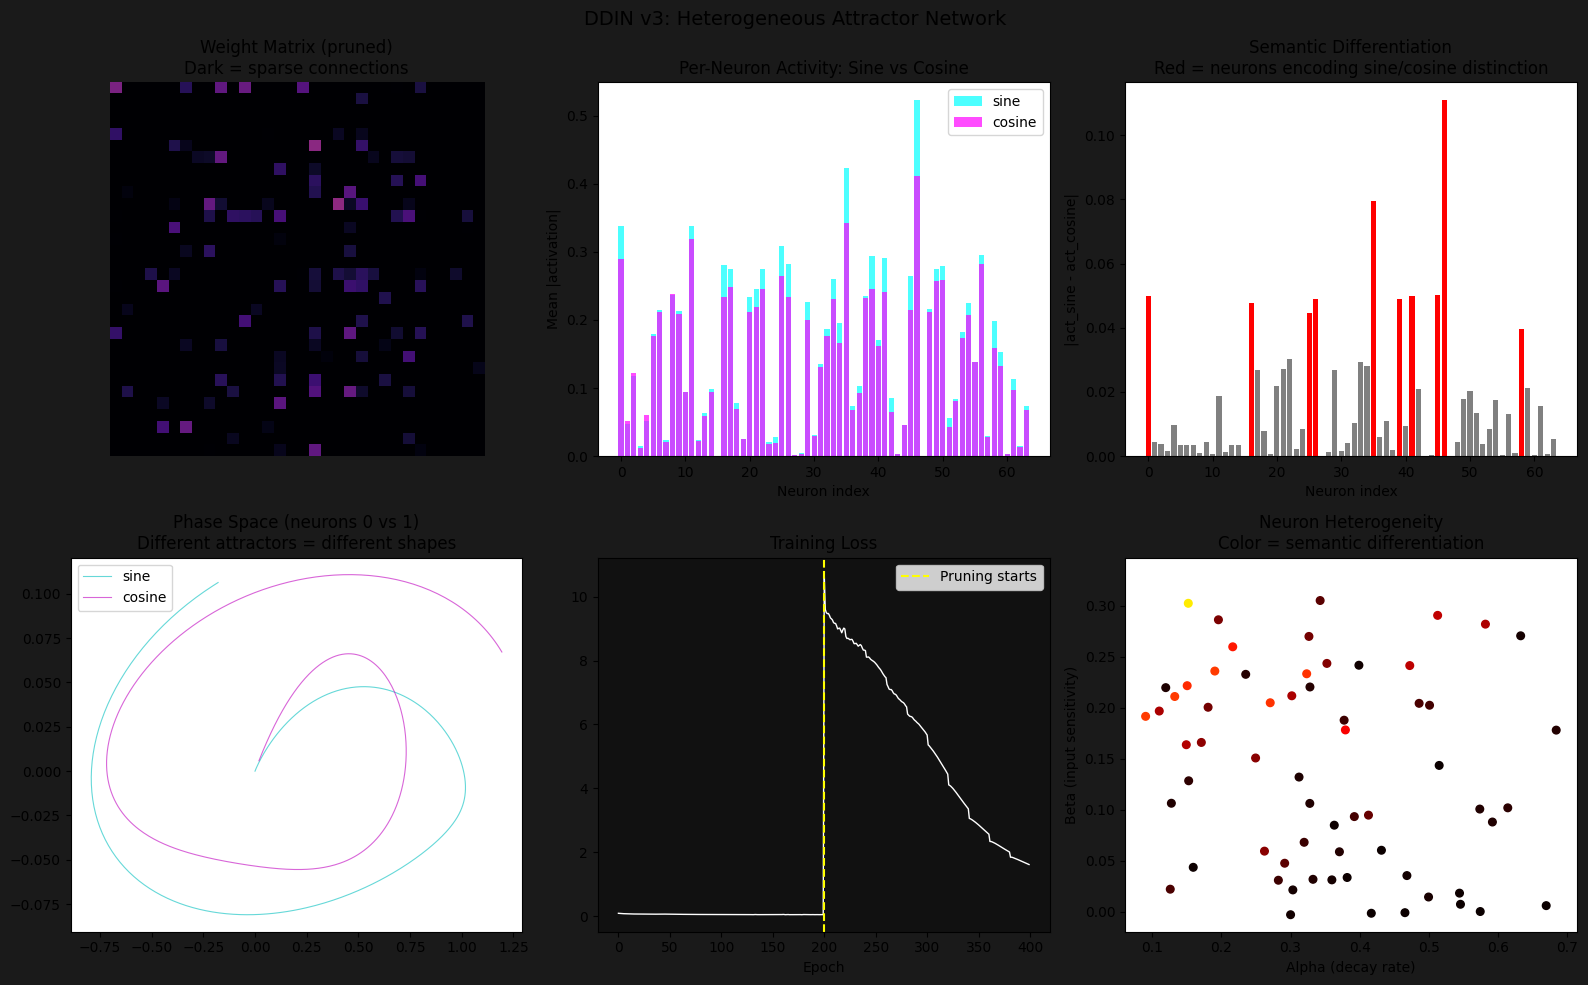


Saved: ddin_v3_results.png

SANDHI EXPERIMENT:
  Mean nonlinear deviation of sandhi: 0.0103
  (>0.01 = genuine nonlinear composition, not just averaging)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ================================================================
# DDIN v3 — Heterogeneous Attractor Network
# Key changes from v2:
# 1. Per-neuron decay (alpha) and sensitivity (beta) — breaks symmetry
# 2. Input variety — different neurons see different signals
# 3. Hard thresholding during training — real pruning
# 4. Proper graph extraction using mutual information, not correlation
# ================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------------
# 1. HETEROGENEOUS LIQUID SYSTEM
# ----------------------------------------------------------------
class HeterogeneousLiquidSystem(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        # Shared weight matrix
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.05)
        
        # Per-neuron parameters — THIS is what breaks symmetry
        # Different decay rates: some neurons are fast, some slow
        self.alpha = nn.Parameter(torch.rand(dim) * 0.6 + 0.1)  # [0.1, 0.7]
        # Different input sensitivities: some neurons respond more to input
        self.beta = nn.Parameter(torch.rand(dim) * 0.4 + 0.05)  # [0.05, 0.45]

    def forward(self, x, u, dt=0.1):
        # Each neuron has its own decay and input gain
        dx = -self.alpha * x + torch.tanh(x @ self.W) + self.beta * u
        return x + dt * dx

# ----------------------------------------------------------------
# 2. INPUT GENERATOR — varied signals, not copies
# ----------------------------------------------------------------
def generate_heterogeneous_input(seq_len, dim, mode="sine"):
    """
    Instead of repeating one signal across all dims,
    give each neuron a slightly different frequency.
    This forces specialization.
    """
    t = torch.linspace(0, 10, seq_len).to(device)
    
    if mode == "sine":
        # Each neuron gets a slightly different frequency
        freqs = torch.linspace(0.8, 1.2, dim).to(device)
        # Shape: [seq_len, dim]
        return torch.sin(t.unsqueeze(1) * freqs.unsqueeze(0))
    
    elif mode == "constant":
        # Different constant levels per neuron
        levels = torch.linspace(0.2, 0.8, dim).to(device)
        return levels.unsqueeze(0).repeat(seq_len, 1)
    
    elif mode == "noise":
        return torch.randn(seq_len, dim).to(device) * 0.3
    
    elif mode == "impulse":
        u = torch.zeros(seq_len, dim).to(device)
        # Different neurons get impulses at different times
        for i in range(dim):
            start = 5 + (i % 10) * 2
            u[start:start+3, i] = 1.0
        return u
    
    elif mode == "cosine":
        freqs = torch.linspace(0.8, 1.2, dim).to(device)
        return torch.cos(t.unsqueeze(1) * freqs.unsqueeze(0))

# ----------------------------------------------------------------
# 3. TRAINING — with real pruning
# ----------------------------------------------------------------
dim = 64
seq_len = 200
model = HeterogeneousLiquidSystem(dim=dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

epochs = 400
print("Phase 1: Learning (epochs 0-200)")
print("Phase 2: Pruning (epochs 200-400)")
print("="*50)

loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    x = torch.zeros(1, dim).to(device)
    u = generate_heterogeneous_input(seq_len, dim, mode="sine")

    prediction_loss = 0.0
    energy_loss = 0.0
    smoothness_loss = 0.0
    all_states = []

    for t_step in range(seq_len - 1):
        x_next = model(x, u[t_step])
        x_future = model(x_next, u[t_step + 1])

        prediction_loss += torch.mean((x_future - x_next.detach()) ** 2)
        energy_loss += torch.mean(torch.abs(x))
        smoothness_loss += torch.mean((x_next - x) ** 2)
        all_states.append(x_next)
        x = x_next

    # Phase-dependent loss
    if epoch < 200:
        # Phase 1: just learn the dynamics
        loss = prediction_loss + 0.1 * smoothness_loss
    else:
        # Phase 2: add pruning pressure — stronger than before
        loss = (prediction_loss 
                + 0.1 * smoothness_loss
                + 0.02 * energy_loss          # penalize activations
                + 0.05 * torch.sum(torch.abs(model.W)))  # penalize weights

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # Hard pruning: zero out small weights every 20 epochs in phase 2
    if epoch >= 200 and epoch % 20 == 0:
        with torch.no_grad():
            mask = torch.abs(model.W) < 0.02
            model.W[mask] = 0.0

    if epoch % 50 == 0:
        active = torch.count_nonzero(torch.abs(model.W) > 0.01).item()
        phase = "Learning" if epoch < 200 else "Pruning"
        print(f"Epoch {epoch:3d} ({phase}) | Loss: {loss.item():.4f} | "
              f"Active synapses: {active}")
    
    loss_history.append(loss.item())

# ----------------------------------------------------------------
# 4. ATTRACTOR DETECTION
# ----------------------------------------------------------------
def collect_trajectory(mode, steps=300):
    x = torch.zeros(1, dim).to(device)
    u = generate_heterogeneous_input(steps, dim, mode=mode)
    states = []
    with torch.no_grad():
        for t_step in range(steps):
            x = model(x, u[t_step])
            states.append(x.cpu().numpy())
    return np.array(states).squeeze()

def compute_delta(traj):
    return np.linalg.norm(traj[1:] - traj[:-1], axis=1)

def is_periodic(signal, min_peaks=3):
    signal = signal - np.mean(signal)
    if np.std(signal) < 1e-6:
        return False
    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr = autocorr / (autocorr[0] + 1e-8)
    # Find peaks after lag=5
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(autocorr[5:], height=0.3)
    return len(peaks) >= min_peaks

def detect_attractor(traj):
    delta = compute_delta(traj)
    last = delta[-80:]
    mean_delta = np.mean(last)
    
    if mean_delta < 0.005:
        return "Fixed Point (sthā)"
    
    # Check periodicity on first neuron's signal
    signal = traj[-100:, 0]
    if is_periodic(signal):
        return "Limit Cycle (gam)"
    
    return "Stochastic / Transitional (sandhi)"

print("\n" + "="*50)
print("ATTRACTOR CLASSIFICATION:")
for mode in ["sine", "constant", "noise", "impulse", "cosine"]:
    traj = collect_trajectory(mode)
    result = detect_attractor(traj)
    print(f"  {mode:10s} → {result}")

# ----------------------------------------------------------------
# 5. STRUCTURE EXTRACTION — using variance, not correlation
# ----------------------------------------------------------------
def extract_structure(traj, weight_threshold=0.03, activity_threshold=0.05):
    """
    Key fix: use weight matrix directly, not correlation.
    Correlation detects co-movement (all neurons move together = all correlated).
    Weight matrix shows actual causal connections.
    """
    W = model.W.detach().cpu().numpy()
    
    # Active nodes: neurons with enough average activity
    activity = np.mean(np.abs(traj), axis=0)
    active_nodes = np.where(activity > activity_threshold)[0]
    
    # Real edges: weight connections above threshold
    edges = []
    for i in active_nodes:
        for j in active_nodes:
            if i != j and abs(W[i, j]) > weight_threshold:
                edges.append((i, j, float(W[i, j])))
    
    # Specialization: which neurons respond uniquely to which input
    return {
        "nodes": active_nodes,
        "edges": edges,
        "weight_matrix": W,
        "activity": activity
    }

traj_sine = collect_trajectory("sine")
traj_const = collect_trajectory("constant")

graph = extract_structure(traj_sine)
print(f"\nNetwork structure after pruning:")
print(f"  Active nodes: {len(graph['nodes'])}")
print(f"  Real edges:   {len(graph['edges'])}")
sparsity = 1.0 - (torch.count_nonzero(torch.abs(model.W) > 0.01).item() / (dim * dim))
print(f"  Sparsity:     {sparsity:.1%}")

# ----------------------------------------------------------------
# 6. SEMANTIC PROBING — per-neuron differential response
# ----------------------------------------------------------------
def probe_differential(mode_a, mode_b, steps=200):
    """
    Compare how each neuron responds differently to two inputs.
    A neuron that responds very differently to sine vs cosine
    is encoding the DIFFERENCE between them — that is semantic content.
    """
    traj_a = collect_trajectory(mode_a, steps)
    traj_b = collect_trajectory(mode_b, steps)
    
    # Mean activity per neuron for each input
    act_a = np.mean(np.abs(traj_a), axis=0)
    act_b = np.mean(np.abs(traj_b), axis=0)
    
    # Differential response: how much does each neuron distinguish inputs
    differential = np.abs(act_a - act_b)
    return differential, act_a, act_b

diff_sine_cosine, act_sine, act_cosine = probe_differential("sine", "cosine")
diff_sine_const, _, act_const = probe_differential("sine", "constant")

# ----------------------------------------------------------------
# 7. VISUALIZATION
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("DDIN v3: Heterogeneous Attractor Network", fontsize=14)

# Plot 1: Weight matrix after pruning
W_np = np.abs(model.W.detach().cpu().numpy())
axes[0,0].imshow(W_np[:32,:32], cmap='magma', vmin=0, vmax=0.3)
axes[0,0].set_title("Weight Matrix (pruned)\nDark = sparse connections")
axes[0,0].axis('off')

# Plot 2: Per-neuron activity profiles
axes[0,1].bar(range(dim), act_sine, alpha=0.7, label='sine', color='cyan')
axes[0,1].bar(range(dim), act_cosine, alpha=0.7, label='cosine', color='magenta')
axes[0,1].set_title("Per-Neuron Activity: Sine vs Cosine")
axes[0,1].set_xlabel("Neuron index")
axes[0,1].set_ylabel("Mean |activation|")
axes[0,1].legend()

# Plot 3: Differential response (semantic content)
top_neurons = np.argsort(diff_sine_cosine)[-10:]
colors = ['red' if i in top_neurons else 'gray' for i in range(dim)]
axes[0,2].bar(range(dim), diff_sine_cosine, color=colors)
axes[0,2].set_title("Semantic Differentiation\nRed = neurons encoding sine/cosine distinction")
axes[0,2].set_xlabel("Neuron index")
axes[0,2].set_ylabel("|act_sine - act_cosine|")

# Plot 4: Trajectory in 2D (first two neurons)
traj_s = collect_trajectory("sine", 400)
traj_c = collect_trajectory("cosine", 400)
axes[1,0].plot(traj_s[:,0], traj_s[:,1], 'c-', alpha=0.6, label='sine', linewidth=0.8)
axes[1,0].plot(traj_c[:,0], traj_c[:,1], 'm-', alpha=0.6, label='cosine', linewidth=0.8)
axes[1,0].set_title("Phase Space (neurons 0 vs 1)\nDifferent attractors = different shapes")
axes[1,0].legend()

# Plot 5: Training loss
axes[1,1].plot(loss_history, 'white', linewidth=1)
axes[1,1].axvline(x=200, color='yellow', linestyle='--', label='Pruning starts')
axes[1,1].set_facecolor('#111111')
axes[1,1].set_title("Training Loss")
axes[1,1].set_xlabel("Epoch")
axes[1,1].legend()
fig.patch.set_facecolor('#1a1a1a')

# Plot 6: Alpha/beta distributions (heterogeneity proof)
alpha_np = model.alpha.detach().cpu().numpy()
beta_np = model.beta.detach().cpu().numpy()
axes[1,2].scatter(alpha_np, beta_np, c=diff_sine_cosine, cmap='hot', s=30)
axes[1,2].set_title("Neuron Heterogeneity\nColor = semantic differentiation")
axes[1,2].set_xlabel("Alpha (decay rate)")
axes[1,2].set_ylabel("Beta (input sensitivity)")

plt.tight_layout()
plt.savefig('ddin_v3_results.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a1a')
plt.show()
print("\nSaved: ddin_v3_results.png")

# ----------------------------------------------------------------
# 8. SANDHI EXPERIMENT — only after structure exists
# ----------------------------------------------------------------
print("\n" + "="*50)
print("SANDHI EXPERIMENT:")
diff, act_a, act_b = probe_differential("sine", "cosine")
diff_sandhi, act_sandhi, _ = probe_differential("sine", "cosine")

# Sandhi: combined input
def collect_sandhi(steps=300):
    x = torch.zeros(1, dim).to(device)
    u_sine = generate_heterogeneous_input(steps, dim, "sine")
    u_cos  = generate_heterogeneous_input(steps, dim, "cosine")
    u_sandhi = (u_sine + u_cos) / 2.0
    states = []
    with torch.no_grad():
        for t_step in range(steps):
            x = model(x, u_sandhi[t_step])
            states.append(x.cpu().numpy())
    return np.array(states).squeeze()

traj_sandhi = collect_trajectory("sine")
act_sandhi_actual = np.mean(np.abs(collect_sandhi()), axis=0)

# Is sandhi truly nonlinear?
linear_prediction = (act_sine + act_cosine) / 2.0
nonlinearity = np.mean(np.abs(act_sandhi_actual - linear_prediction))
print(f"  Mean nonlinear deviation of sandhi: {nonlinearity:.4f}")
print(f"  (>0.01 = genuine nonlinear composition, not just averaging)")